In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

claims = pd.read_csv("../data/raw/Car_Insurance_Claim.csv")
motor  = pd.read_csv("../data/raw/motor_data14-2018.csv")

print("Claims shape:", claims.shape)
print("Motor shape:", motor.shape)

Claims shape: (10000, 19)
Motor shape: (508499, 16)


In [17]:
print(claims.dtypes)
print("\nMissing values:")
print(claims.isnull().sum())
claims.head()

ID                       int64
AGE                     object
GENDER                  object
RACE                    object
DRIVING_EXPERIENCE      object
EDUCATION               object
INCOME                  object
CREDIT_SCORE           float64
VEHICLE_OWNERSHIP      float64
VEHICLE_YEAR            object
MARRIED                float64
CHILDREN               float64
POSTAL_CODE              int64
ANNUAL_MILEAGE         float64
VEHICLE_TYPE            object
SPEEDING_VIOLATIONS      int64
DUIS                     int64
PAST_ACCIDENTS           int64
OUTCOME                float64
dtype: object

Missing values:
ID                       0
AGE                      0
GENDER                   0
RACE                     0
DRIVING_EXPERIENCE       0
EDUCATION                0
INCOME                   0
CREDIT_SCORE           982
VEHICLE_OWNERSHIP        0
VEHICLE_YEAR             0
MARRIED                  0
CHILDREN                 0
POSTAL_CODE              0
ANNUAL_MILEAGE         957
VE

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [18]:
print(motor.dtypes)
print("\nMissing values:")
print(motor.isnull().sum())
motor.head()

SEX                    int64
INSR_BEGIN            object
INSR_END              object
EFFECTIVE_YR          object
INSR_TYPE              int64
INSURED_VALUE        float64
PREMIUM              float64
OBJECT_ID              int64
PROD_YEAR            float64
SEATS_NUM            float64
CARRYING_CAPACITY    float64
TYPE_VEHICLE          object
CCM_TON              float64
MAKE                  object
USAGE                 object
CLAIM_PAID           float64
dtype: object

Missing values:
SEX                       0
INSR_BEGIN                0
INSR_END                  0
EFFECTIVE_YR              3
INSR_TYPE                 0
INSURED_VALUE             0
PREMIUM                  13
OBJECT_ID                 0
PROD_YEAR                63
SEATS_NUM                95
CARRYING_CAPACITY    116834
TYPE_VEHICLE              0
CCM_TON                   6
MAKE                      5
USAGE                     0
CLAIM_PAID           470727
dtype: int64


,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-17,07-AUG-18,08,1202,519755.22,5097.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-16,07-AUG-17,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-15,07-AUG-16,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-AUG-14,07-AUG-15,08,1202,519755.22,5102.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-17,07-AUG-18,08,1202,1400000.00,13304.87,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,NaN


OUTCOME
0.0    6867
1.0    3133
Name: count, dtype: int64


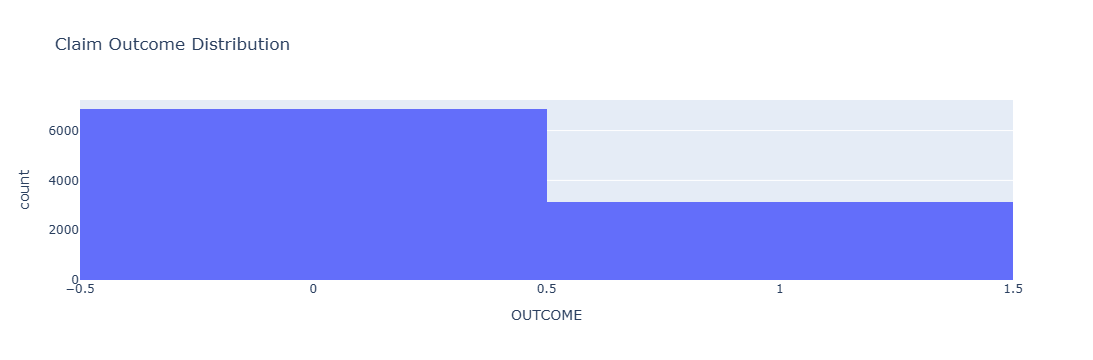

In [19]:
print(claims["OUTCOME"].value_counts())
px.histogram(claims, x="OUTCOME", title="Claim Outcome Distribution")

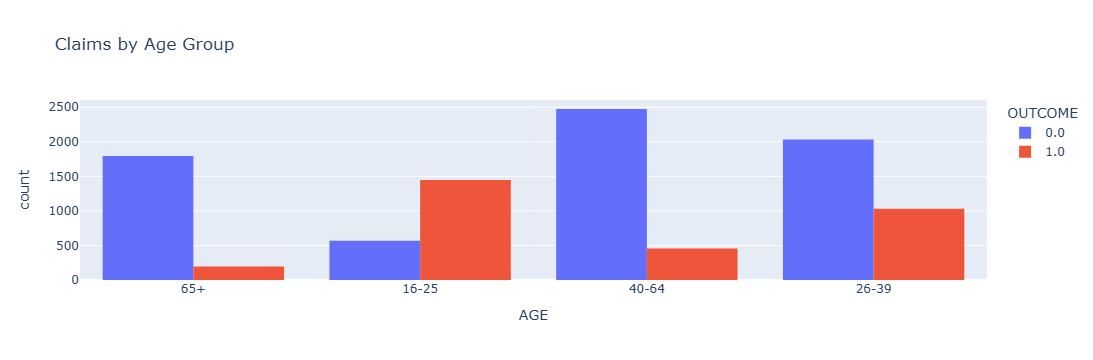

In [20]:
px.histogram(claims, x="AGE", color="OUTCOME", barmode="group",
             title="Claims by Age Group")

% rows with claim paid: 7.421253532455324


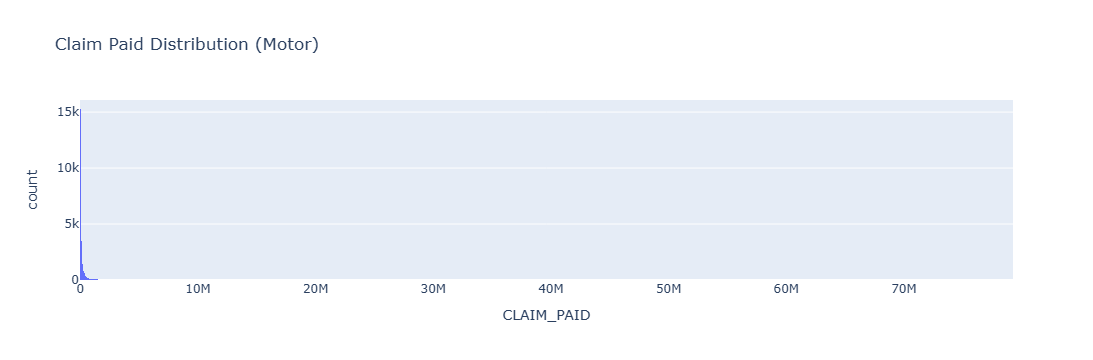

In [22]:
motor["CLAIM_PAID"] = pd.to_numeric(motor["CLAIM_PAID"], errors="coerce")
print("% rows with claim paid:", (motor["CLAIM_PAID"] > 0).mean() * 100)
px.histogram(motor[motor["CLAIM_PAID"] > 0], x="CLAIM_PAID",
             title="Claim Paid Distribution (Motor)")

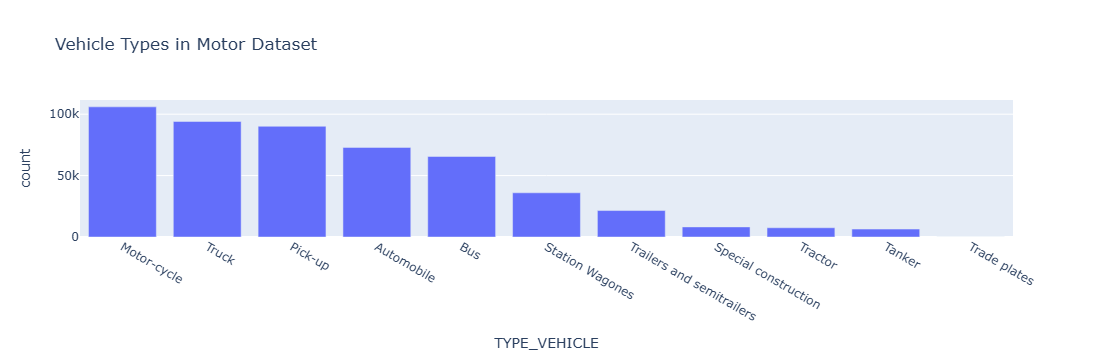

In [23]:
px.bar(motor["TYPE_VEHICLE"].value_counts().reset_index(),
       x="TYPE_VEHICLE", y="count", title="Vehicle Types in Motor Dataset")